In [6]:
library(data.table)
library(ggplot2)
library(dplyr)

In [37]:
sce = readRDS('sce.rds')

In [3]:
sce

class: SingleCellExperiment 
dim: 30725 146133 
metadata(0):
assays(2): counts logcounts
rownames(30725): WDR31 RNF183 ... ENSG00000175602 ENSG00000172324
rowData names(2): ensembl_id gene_name
colnames(146133): cell_1 cell_2 ... cell_172994 cell_172995
colData names(15): cell barcode ... celltype singler_ext
reducedDimNames(3): UMAP TSNE PCA
mainExpName: NULL
altExpNames(0):

In [26]:
#meta = as.data.table(colData(sce), keep.rownames=F)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [39]:
meta = fread('rna_meta.tsv')

In [40]:
unique(meta$celltype)

[1] "Epiblast"                             
 [2] "Hypoblast"                            
 [3] "Primitive Streak"                     
 [4] "Trophoblast"                          
 [5] "Nascent mesoderm"                     
 [6] "Haematoendothelial progenitors"       
 [7] "Anterior Primitive Streak"            
 [8] "Parietal YS endoderm"                 
 [9] "PGC"                                  
[10] "Allantois endothelium"                
[11] "Visceral endoderm"                    
[12] "Amnion 1"                             
[13] "Cytotrophoblast"                      
[14] "Definitive Endoderm"                  
[15] "Cardiopharyngeal progenitors"         
[16] "Embryo proper endothelium"            
[17] "Visceral YS endoderm 2"               
[18] "Gut endoderm"                         
[19] "EMP"                                  
[20] "Placodal ectoderm"                    
[21] "Amnion 2"                             
[22] "Lateral plate mesoderm"               
[23] "Notochord"                            
[24] "NMPs"                                 
[25] "Non-neural ectoderm 4"                
[26] "Pharyngeal endoderm"                  
[27] "Dermomyotome"                         
[28] "MEP"                                  
[29] "Cranial mesoderm"                     
[30] "Visceral YS endoderm"                 
[31] "Caudal mesoderm"                      
[32] "Mesenchyme"                           
[33] "Anterior somitic tissues"             
[34] "Forebrain"                            
[35] "Anterior cardiopharyngeal progenitors"
[36] "Cardiomyocytes FHF 1"                 
[37] "Syncytiotrophoblast"                  
[38] "Syncytiotrophoblast progenitors"      
[39] "Venous endothelium"                   
[40] "Erythroid"                            
[41] "Hindbrain"                            
[42] "Mesothelium"                          
[43] "NMPs/Mesoderm-biased"                 
[44] "Cardiomyocytes FHF 2"                 
[45] "YS endothelium"                       
[46] "Sclerotome"                           
[47] "Presomitic mesoderm"                  
[48] "Spinal cord"                          
[49] "Allantois"                            
[50] "Endocardium"                          
[51] "Somitic mesoderm"                     
[52] "Epicardium"                           
[53] "Posterior somitic tissues"            
[54] "Midbrain"                             
[55] "Gut tube"                             
[56] "Nephron progenitors"                  
[57] "Amnion 3"                             
[58] "Differentiating neurons"              
[59] "Limb mesoderm"                        
[60] "Thyroid primordium"                   
[61] "Floor plate"                          
[62] "Migratory neural crest"               
[63] "Non-neural ectoderm 2"                
[64] "Cranial neural crest"                 
[65] "Roof plate"                           
[66] "Megakariocytes"                       
[67] "Mesothelium-endothelium/Masked"

In [36]:
head(test)

V1,cell,barcode,sample,stage,doub.density,doublet,stripped,sizeFactor,celltype,⋯,leiden_res2_5,leiden_res3,leiden_res5,leiden_res10,leiden_res6,leiden_res7,leiden_res8,anatomical_loc,day,somite_count
<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<lgl>,<lgl>,<dbl>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>
cell_1,cell_1,AAACCCAAGCCTTCTC,1,GD7,6.367198,FALSE,FALSE,1.2152048,Epiblast,⋯,7,6,20,30,13,12,7,Whole embryo,7,0
cell_2,cell_2,AAACCCACACAATGAA,1,GD7,0.000000,FALSE,FALSE,0.8610570,Hypoblast,⋯,11,10,39,37,42,41,39,Whole embryo,7,0
cell_4,cell_4,AAACCCAGTAGGTTTC,1,GD7,43.049333,FALSE,FALSE,0.5699888,Primitive Streak,⋯,7,6,20,75,13,12,7,Whole embryo,7,0
cell_5,cell_5,AAACCCATCTGGACTA,1,GD7,8.402787,FALSE,FALSE,0.8911607,Trophoblast,⋯,17,15,8,9,24,21,15,Whole embryo,7,0
cell_6,cell_6,AAACGAAAGGTGAGAA,1,GD7,61.325550,FALSE,FALSE,1.3621865,Nascent mesoderm,⋯,32,31,36,59,37,42,59,Whole embryo,7,0
cell_9,cell_9,AAACGCTAGATGTAGT,1,GD7,94.302222,FALSE,FALSE,0.7871996,Hypoblast,⋯,18,19,11,45,5,30,37,Whole embryo,7,0


In [27]:
# celltypes_keep = c('EMP', 'Embryo proper endothelium', 'Allantois endothelium', 'Venous endothelium', 'YS endothelium')
# meta = meta[celltype %in% celltypes_keep]

In [41]:
celltypes_keep = c('Haematoendothelial progenitors', 'EMP', 'Embryo proper endothelium', 'Allantois endothelium', 'Venous endothelium', 'YS endothelium')
meta = meta[celltype %in% celltypes_keep]

In [42]:
nrow(meta)

[1] 7358

In [43]:
sce = sce[, meta$cell]

In [44]:
sce

class: SingleCellExperiment 
dim: 30725 7358 
metadata(0):
assays(2): counts logcounts
rownames(30725): WDR31 RNF183 ... ENSG00000175602 ENSG00000172324
rowData names(2): ensembl_id gene_name
colnames(7358): cell_15 cell_18 ... cell_172992 cell_172994
colData names(15): cell barcode ... celltype singler_ext
reducedDimNames(3): UMAP TSNE PCA
mainExpName: NULL
altExpNames(0):

In [45]:
genes = as.data.table(as.matrix(t(logcounts(sce[c('LYVE1', 'FXYD6')]))), keep.rownames=T) %>% setnames('rn', 'cell')

In [46]:
meta_genes = merge(meta, genes, by = 'cell')

In [47]:
head(meta_genes)

cell,V1,barcode,sample,stage,doub.density,doublet,stripped,sizeFactor,celltype,⋯,leiden_res5,leiden_res10,leiden_res6,leiden_res7,leiden_res8,anatomical_loc,day,somite_count,LYVE1,FXYD6
<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<lgl>,<lgl>,<dbl>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<dbl>,<dbl>
cell_10000,cell_10000,TGTTCATAGCTGACAG,3,GD7,15.31045,FALSE,FALSE,2.3995568,Haematoendothelial progenitors,⋯,36,70,37,42,57,Whole embryo,7,0,0.000000,0.5025787
cell_100020,cell_100020,AAAGTCCGTGTTTACG,19,GD9,37.85333,FALSE,FALSE,0.5243391,YS endothelium,⋯,34,35,32,32,46,Yolk sac,9,16,0.000000,0.0000000
cell_100029,cell_100029,AAAGTGATCACCTACC,19,GD9,0.00000,FALSE,FALSE,0.2908309,YS endothelium,⋯,34,35,32,32,46,Yolk sac,9,16,2.150048,2.9776185
cell_100042,cell_100042,AAATGGAGTGCCGGTT,19,GD9,0.00000,FALSE,FALSE,0.3585875,YS endothelium,⋯,34,35,32,32,46,Yolk sac,9,16,0.000000,0.0000000
cell_100045,cell_100045,AAATGGATCACAATGC,19,GD9,0.00000,FALSE,FALSE,0.4254645,YS endothelium,⋯,34,88,32,32,76,Yolk sac,9,16,0.000000,1.7443216
cell_100064,cell_100064,AACAAGAAGCCATTTG,19,GD9,0.00000,FALSE,FALSE,0.6167889,EMP,⋯,37,82,39,40,71,Yolk sac,9,16,0.000000,0.0000000


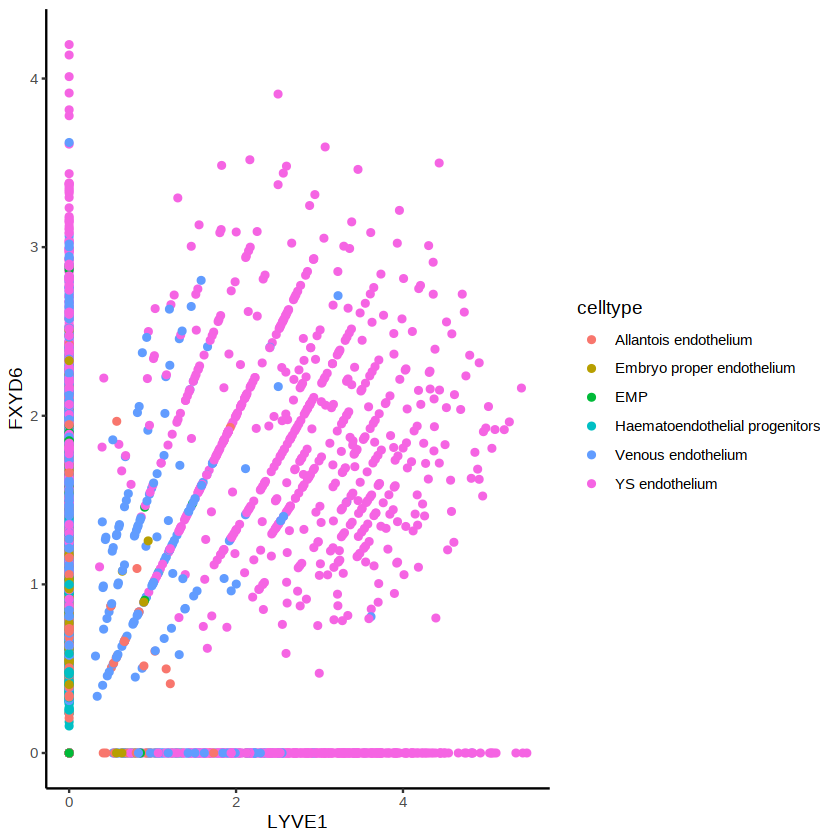

In [48]:
ggplot(meta_genes, aes(LYVE1, FXYD6, col=celltype)) + 
    geom_point() + 
    theme_classic()

In [62]:
options(repr.plot.width=20, repr.plot.height=20)

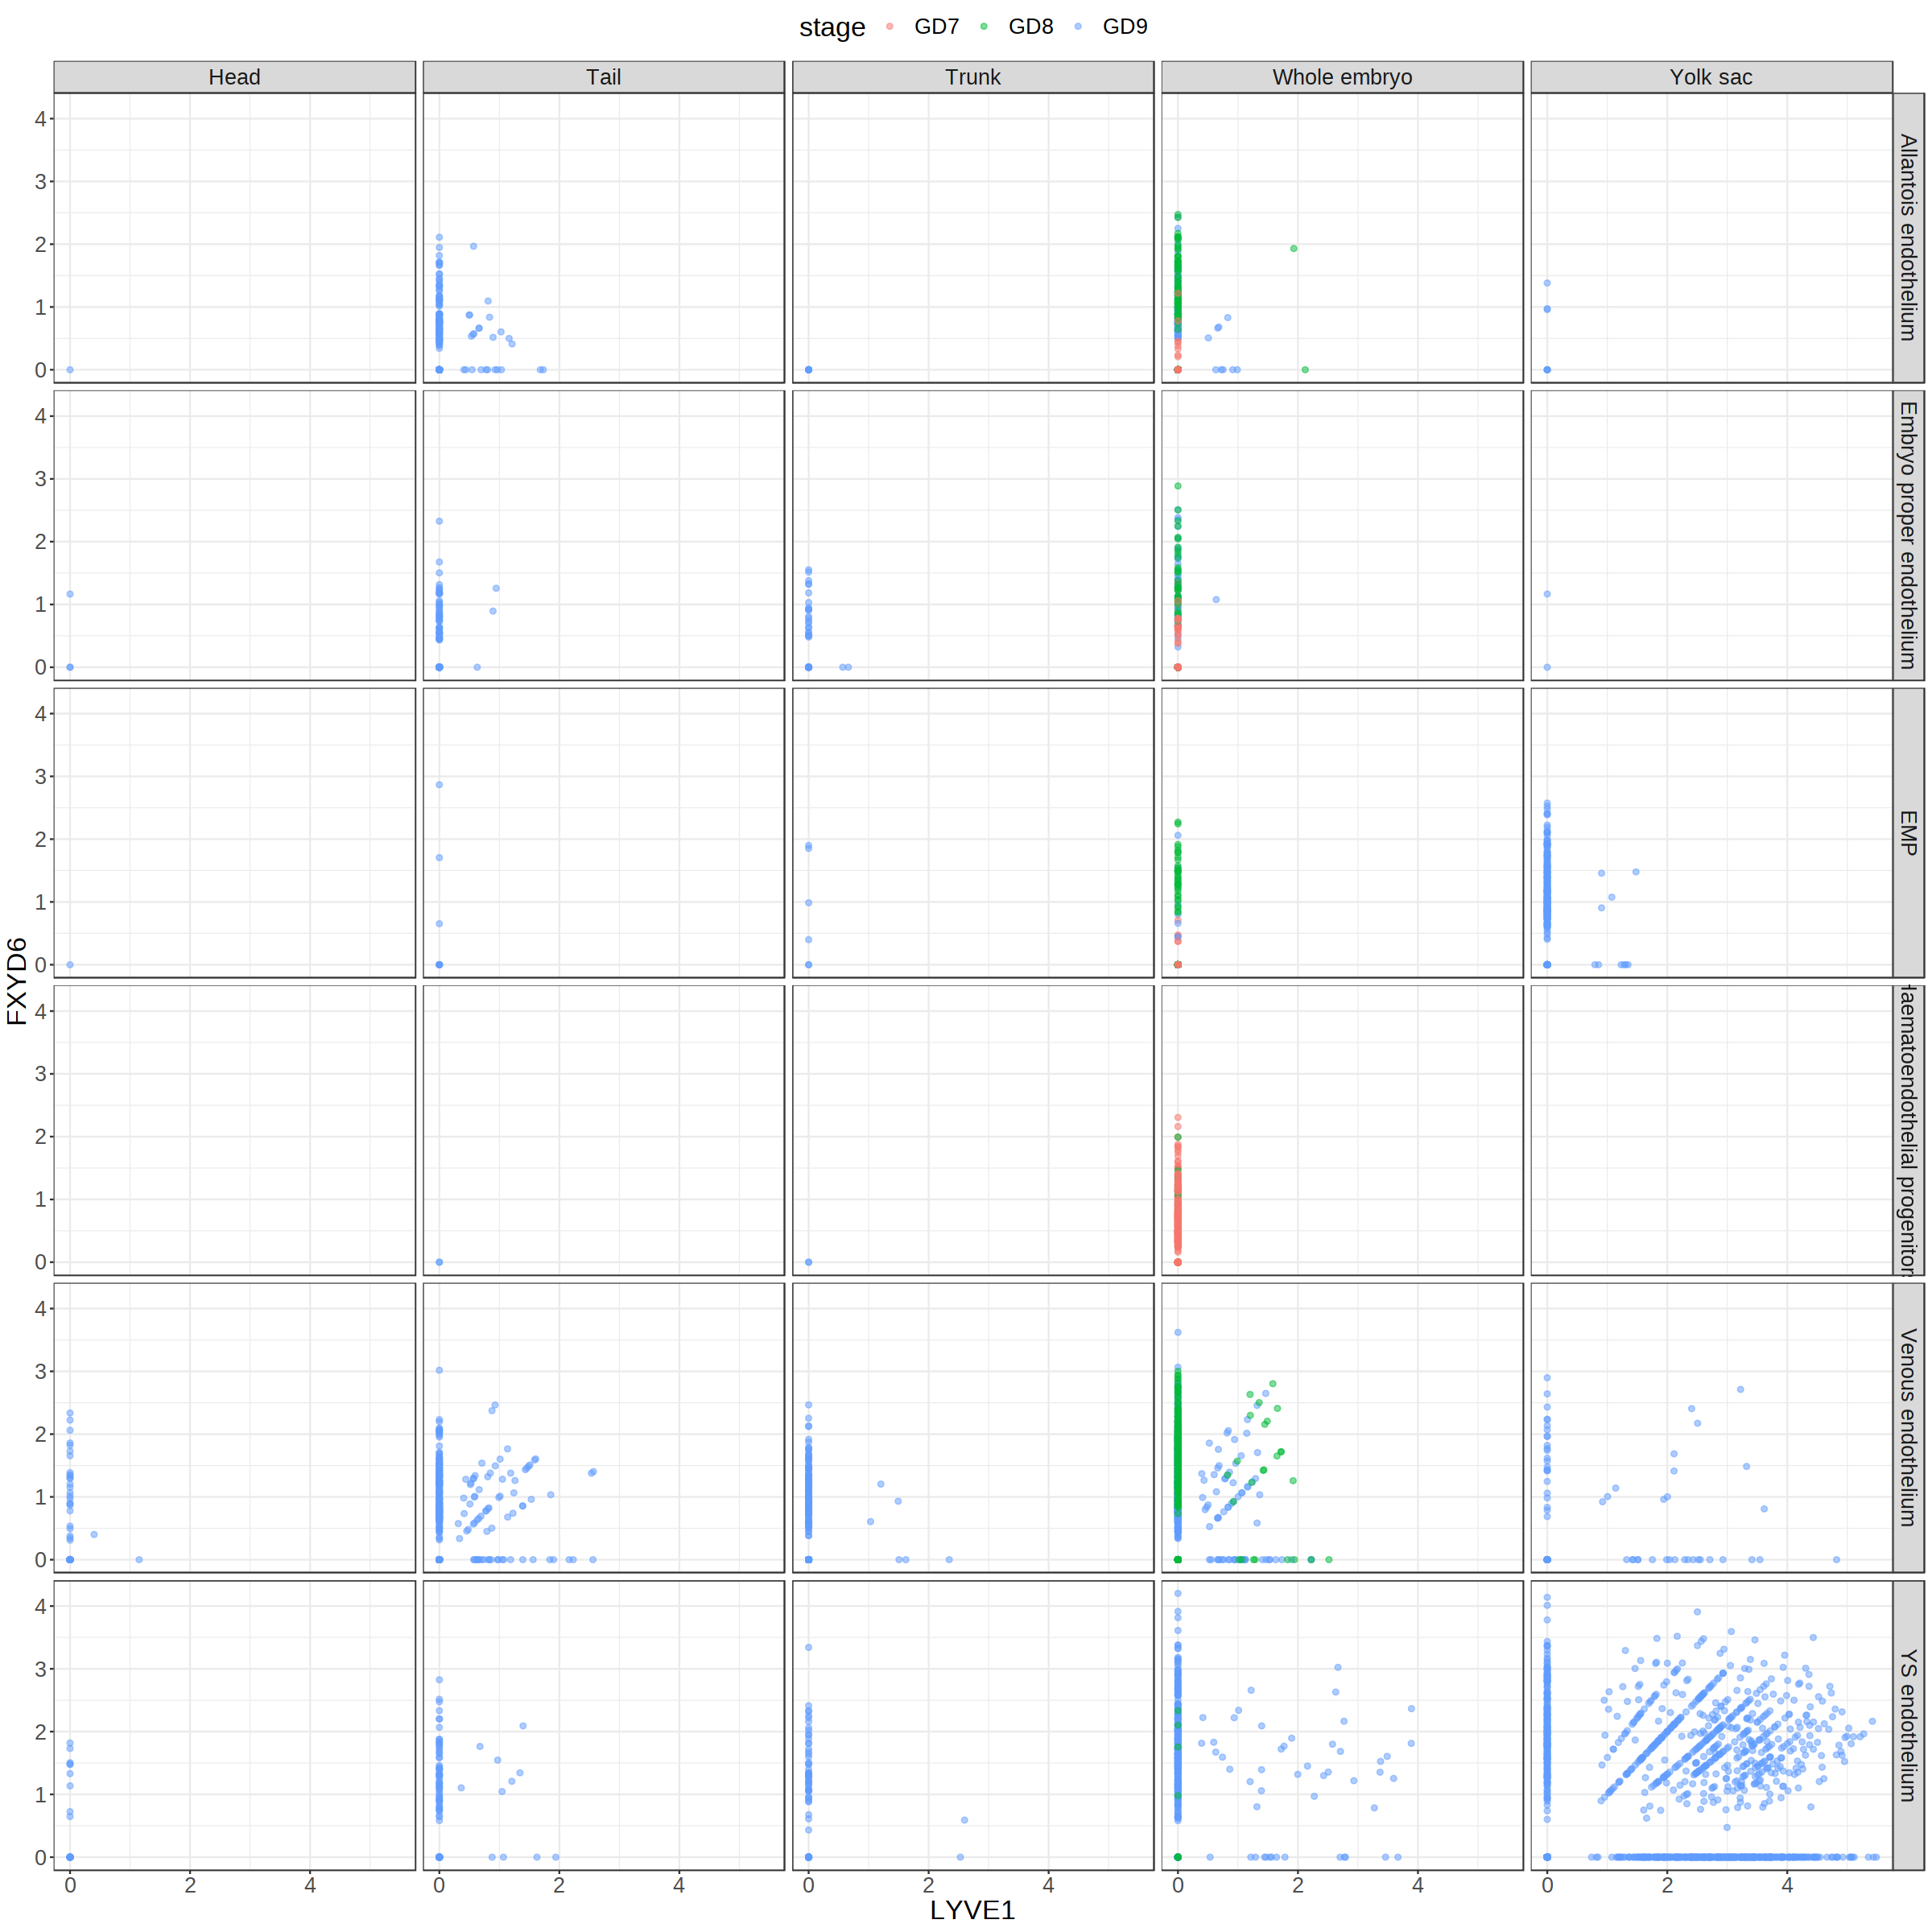

In [69]:
ggplot(meta_genes, aes(LYVE1, FXYD6, col=stage)) + 
    geom_point(alpha=0.5) +
    facet_grid(celltype ~ anatomical_loc) + 
    theme_bw() + theme(legend.position='top', 
                            text=element_text(size=20, color='black'))